# GPU Sgr A* SMBH Time-Dependent Simulation
GPU-accelerated version of the Sgr A* supermassive black hole accretion disk simulation.
Uses `blackhole.gpu.simulation.run_simulation` with SMBH-specific parameters:
auto-scaled `sigma_cap`, `dt_max`, and thermal-timescale dt constraint.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

from blackhole.constants import M_sun
from blackhole.gpu import is_gpu_available
from blackhole.gpu.perf_logger import PerformanceLogger
from blackhole.gpu.simulation import SimulationConfig, run_simulation

print(f"GPU available: {is_gpu_available()}")
if is_gpu_available():
    import cupy as cp
    print(f"CuPy device: {cp.cuda.runtime.getDeviceProperties(0)['name'].decode()}")

GPU available: True
CuPy device: NVIDIA GeForce RTX 5080 Laptop GPU


In [2]:
cfg = SimulationConfig(
    M_star=M_sun * 4.3e6,
    R_1=4e12,
    R_K=1e15,
    R_N=2e15,
    M_dot=1e22,
    alpha_cold=0.02,
    alpha_hot=0.2,
    N_base=10_000,
    N_n=3,
    min_Sigma=1e-5,
    timesteps=500_001,
    output_interval=5,
    dt_min=1e5,
    tidal_params={"cw": 0.2, "a_1": 1.5e16, "n_1": 5, "trunc_frac": 9.3 / 10},
    enable_irradiation=True,
    enable_evaporation=True,
    theta=0.5,
    sigma_cap=None,
    use_gpu=True,
)

pl = PerformanceLogger()

t0 = time.time()
result = run_simulation(cfg, perf_logger=pl)
elapsed = time.time() - t0
print(f"Simulation complete: {len(result.t_history)} snapshots in {elapsed:.1f} s")
print(f"Total simulated time: {result.t_history[-1]:.2e} s")

Simulation complete: 40001 snapshots in 17228.1 s
Total simulated time: 1.96e+13 s


In [3]:
import os

# Read the latest run via the 'latest' pointer
latest_path = os.path.join("logs", "latest")
if os.path.islink(latest_path):
    run_name = os.readlink(latest_path)
elif os.path.isfile(latest_path):
    with open(latest_path) as f:
        run_name = f.read().strip()
else:
    run_name = None

if run_name:
    summary_path = os.path.join("logs", run_name, "summary.txt")
    print(f"Run: {run_name}\n")
    with open(summary_path) as f:
        print(f.read())
else:
    print("No profiling logs found. Run the simulation with perf_logger first.")

Run: 20260226_103844

Stage                           Total (s)   Count   Avg (ms)       %
--------------------------------------------------------------------
alpha_viscosity                  5176.804  200001     25.884   30.1%
add_mass                         3535.587  200001     17.678   20.5%
irradiation                      2432.152  200001     12.161   14.1%
solve_temperature                2224.134  200001     11.121   12.9%
evolve_surface_density           2031.938  200001     10.160   11.8%
solve_scale_height                628.974  200001      3.145    3.6%
thermal_dt_check                  515.940  200001      2.580    3.0%
snapshot                          348.720   40000      8.718    2.0%
evap_setup                        167.836  200001      0.839    1.0%
kinematic_viscosity               159.463  200001      0.797    0.9%
--------------------------------------------------------------------
TOTAL                           17221.548



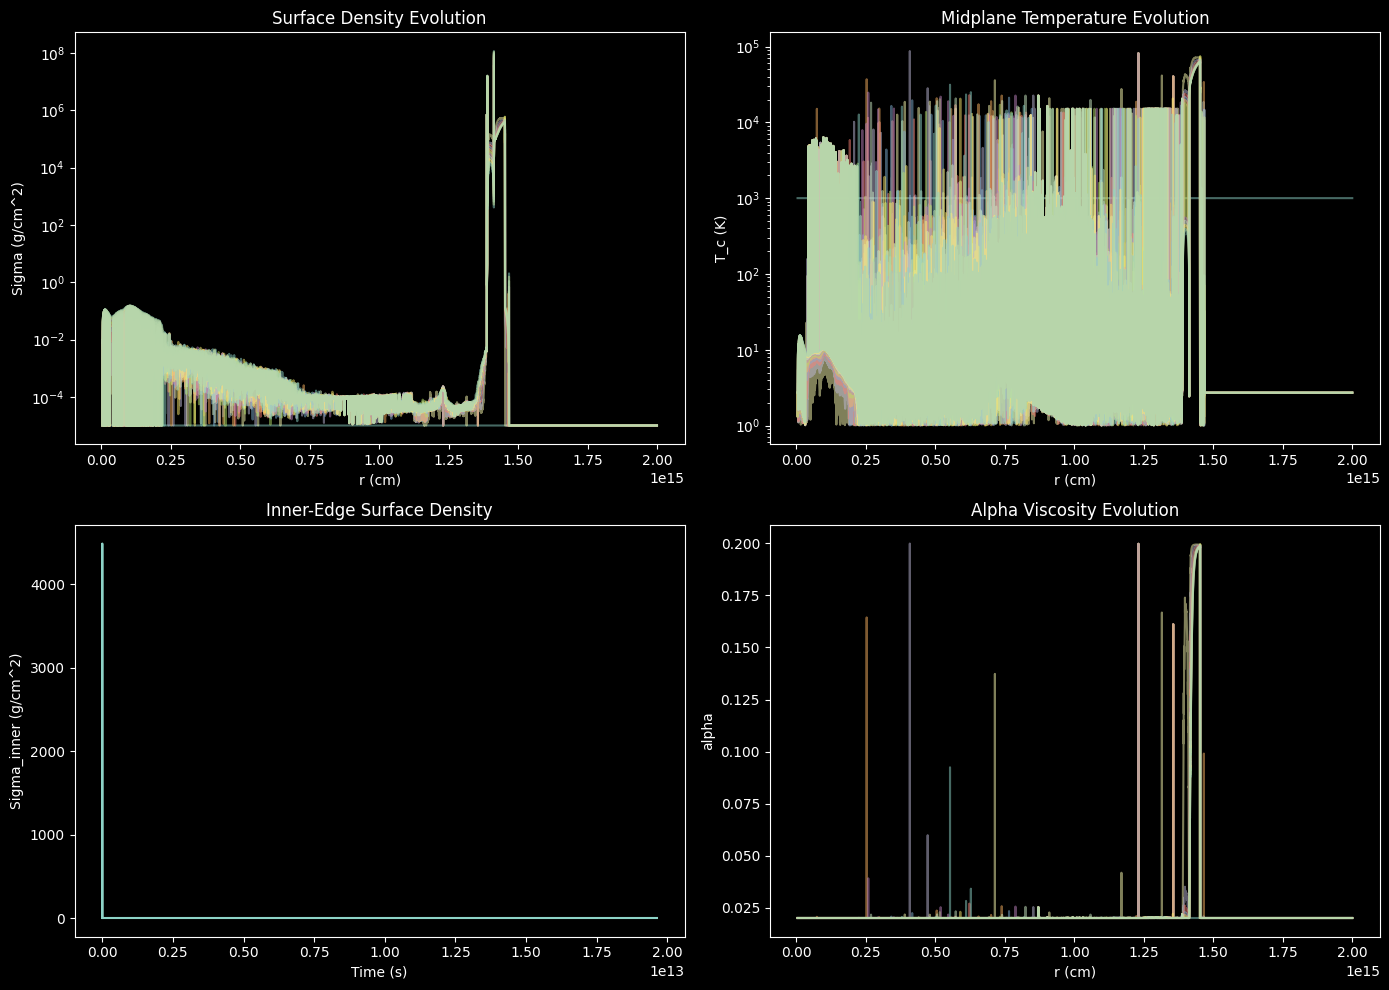

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

r_grid = np.linspace(cfg.R_1, cfg.R_N, len(result.Sigma_history[0]))

# Surface density evolution
ax = axes[0, 0]
for i in range(0, len(result.Sigma_history), max(1, len(result.Sigma_history) // 10)):
    ax.semilogy(r_grid, result.Sigma_history[i], alpha=0.5)
ax.set_xlabel("r (cm)")
ax.set_ylabel("Sigma (g/cm^2)")
ax.set_title("Surface Density Evolution")

# Temperature evolution
ax = axes[0, 1]
for i in range(0, len(result.Temp_history), max(1, len(result.Temp_history) // 10)):
    ax.semilogy(r_grid, result.Temp_history[i], alpha=0.5)
ax.set_xlabel("r (cm)")
ax.set_ylabel("T_c (K)")
ax.set_title("Midplane Temperature Evolution")

# Inner-edge Sigma vs time
ax = axes[1, 0]
ax.plot(result.t_history, result.Sigma_transfer_history)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Sigma_inner (g/cm^2)")
ax.set_title("Inner-Edge Surface Density")

# Alpha viscosity evolution
ax = axes[1, 1]
for i in range(0, len(result.alpha_history), max(1, len(result.alpha_history) // 10)):
    ax.plot(r_grid, result.alpha_history[i], alpha=0.5)
ax.set_xlabel("r (cm)")
ax.set_ylabel("alpha")
ax.set_title("Alpha Viscosity Evolution")

plt.tight_layout()
plt.show()

In [5]:
import os

DATA_DIR = "../../data"
os.makedirs(DATA_DIR, exist_ok=True)
SUFFIX = "_history_bath_array_gpu.csv"

np.savetxt(f"{DATA_DIR}/Sigma{SUFFIX}", np.array(result.Sigma_history), delimiter=",")
np.savetxt(f"{DATA_DIR}/Temp{SUFFIX}", np.array(result.Temp_history), delimiter=",")
np.savetxt(f"{DATA_DIR}/H{SUFFIX}", np.array(result.H_history), delimiter=",")
np.savetxt(f"{DATA_DIR}/alpha{SUFFIX}", np.array(result.alpha_history), delimiter=",")
np.savetxt(f"{DATA_DIR}/t{SUFFIX}", np.array(result.t_history), delimiter=",")
np.savetxt(f"{DATA_DIR}/Sigma_transfer{SUFFIX}", np.array(result.Sigma_transfer_history), delimiter=",")

print(f"Saved 6 CSV files to {DATA_DIR}/ with suffix '{SUFFIX}'")

Saved 6 CSV files to ../../data/ with suffix '_history_bath_array_gpu.csv'


## Notes
- **SMBH parameters**: M = 4.3e6 M_sun, alpha_cold = 0.02, M_dot = 1e22 g/s.
- `sigma_cap=None` triggers auto-scaling from `Sigma_max` (yields ~720,000 g/cm^2).
- **Auto-dt**: the timestep ceiling is automatically computed from physics constraints
  (mass deposition limit and thermal timescale at R_K). During outbursts, the per-radius
  thermal constraint reduces dt to resolve the alpha transition.
- `dt_min=1e5` provides a higher floor for extreme inner-radius outbursts in the SMBH regime.
- Set `use_gpu=False` to run on CPU with the same orchestrator.